# 1. 1차원데이터분석

1. 변수종류파악( 수치형/ 범주형/ 시간형)

2. 변수종류별분석지표( 수치형/ 범주형/ 시간형)

3. 시각화 : 도수분포표/ 히스토그램/ 상자그림


# 2. 2차원데이터분석

1.상관계수

2.시각화 : 산점도/ 회귀직선/ 히트맵

# 항공사 지연요인 데이터 탐색적 분석

출처 : https://www.kaggle.com/datasets/pitterman/airline-stats



- airline : 항공사
- carrier_deay : 항공사 지연 요인
- atc_delay : ATC 항공교통관제 지연 요인
- weather_delay : 날씨로 인한 지연 요인

In [ ]:
import kagglehub
import pandas as pd
import shutil
import os


# Download latest version
filename = 'airline_stats.csv'

down_path = kagglehub.dataset_download("pitterman/airline-stats", r".\data")
print("Downloaded Path :", down_path)

# src_file = "\\".join([down_path, filename])
# dest_file = "\\".join([".\\data", filename])
# print(src_file, dest_file)

# # 3. 파일 이동 (또는 복사)
# if not os.path.isfile(dest_file) :
#     shutil.move(src_file, dest_file)

In [ ]:
# !pip install kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import os

api = KaggleApi()
api.authenticate()

# path 파라미터로 저장 폴더 지정 가능

data_set = "pitterman/airline-stats"
filename = "airline-stats.csv"

api.dataset_download_files(data_set, path="./data", unzip=True)

dest_file = "\\".join([".\\data", filename])
print("File Exists :", os.path.isfile(dest_file)) 

OSError: Could not find kaggle.json. Make sure it's located in C:\Users\Admin\.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/

In [ ]:
import pandas as pd

In [41]:
ailine_file = r".\data\airline_stats.csv"

airline_df= pd.read_csv("\\".join(['.\\data', filename])) 
airline_df

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


In [15]:
# 1. 변수종류파악( 수치형/ 범주형/ 시간형)
airline_df.info()

# 2. 변수종류별분석지표( 수치형/ 범주형/ 시간형)

# 3. 시각화 : 도수분포표/ 히스토그램/ 상자그림

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33468 entries, 0 to 33467
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pct_carrier_delay  33440 non-null  float64
 1   pct_atc_delay      33440 non-null  float64
 2   pct_weather_delay  33440 non-null  float64
 3   airline            33468 non-null  object 
dtypes: float64(3), object(1)
memory usage: 1.0+ MB


# 항공사 현황 탐색

In [16]:
airline_df['airline'].unique()

array(['American', 'Alaska', 'Jet Blue', 'Delta', 'United', 'Southwest'],
      dtype=object)

In [19]:
airline_df['airline'].value_counts()


airline
Delta        9107
American     5725
Southwest    5584
United       5426
Alaska       3851
Jet Blue     3775
Name: count, dtype: int64

In [21]:
# 통계 지표
airline_df.describe()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay
count,33440.000000,33440.000000,33440.000000
mean,7.041475,5.089962,0.684776
std,4.497596,4.718647,1.073743
min,0.000000,0.000000,0.000000
25%,4.145455,2.146565,0.000000
50%,6.356893,3.900000,0.316002
75%,9.140474,6.630238,0.935161
max,100.000000,100.000000,33.333333


In [27]:
airline_df.groupby('airline')['pct_carrier_delay'].describe()
airline_df.groupby('airline')['pct_carrier_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,3.521889,9.042180,6.333460,8.081843,7.521997,7.398833
std,2.483224,4.139067,4.695292,3.797737,3.345085,5.369283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.935484,6.338538,3.813989,5.341176,5.070294,4.034708
50%,3.225806,8.428571,5.548387,7.657895,6.960930,6.445210
75%,4.685599,10.988763,7.821952,10.280000,9.354839,9.633110
max,22.290323,50.000000,100.000000,28.000000,24.800000,100.000000


In [28]:
airline_df.groupby('airline')['pct_atc_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,5.472672,5.993529,4.462978,7.345231,3.147019,5.348133
std,5.699303,4.647170,4.364335,5.227372,2.513162,4.992464
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.878614,3.108403,1.818182,3.784314,1.612527,2.431308
50%,3.776860,4.986523,3.508108,6.136905,2.559242,4.353647
75%,7.001330,7.594450,5.839901,9.612903,3.790421,7.030109
max,54.838710,60.000000,100.000000,40.986111,21.542722,100.000000


In [29]:
airline_df.groupby('airline')['pct_weather_delay'].describe().T

airline,Alaska,American,Delta,Jet Blue,Southwest,United
count,3851.000000,5723.000000,9095.000000,3773.000000,5584.000000,5414.000000
mean,0.513497,1.122920,0.680765,0.465327,0.512611,0.680697
std,1.136494,1.097811,1.093255,0.764147,0.649631,1.338433
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.296719,0.000000,0.000000,0.105675,0.000000
50%,0.000000,0.884354,0.316406,0.157312,0.305598,0.263780
75%,0.497395,1.641725,0.893346,0.666667,0.663306,0.861395
max,14.633803,12.500000,20.500000,9.923077,6.240987,33.333333


# 결측치

In [30]:
airline_df.isnull().sum()

pct_carrier_delay    28
pct_atc_delay        28
pct_weather_delay    28
airline               0
dtype: int64

# 2. 변수종류별분석지표( 수치형/ 범주형/ 시간형)

- histogram 으로 비교

In [31]:
from matplotlib import pyplot as plt

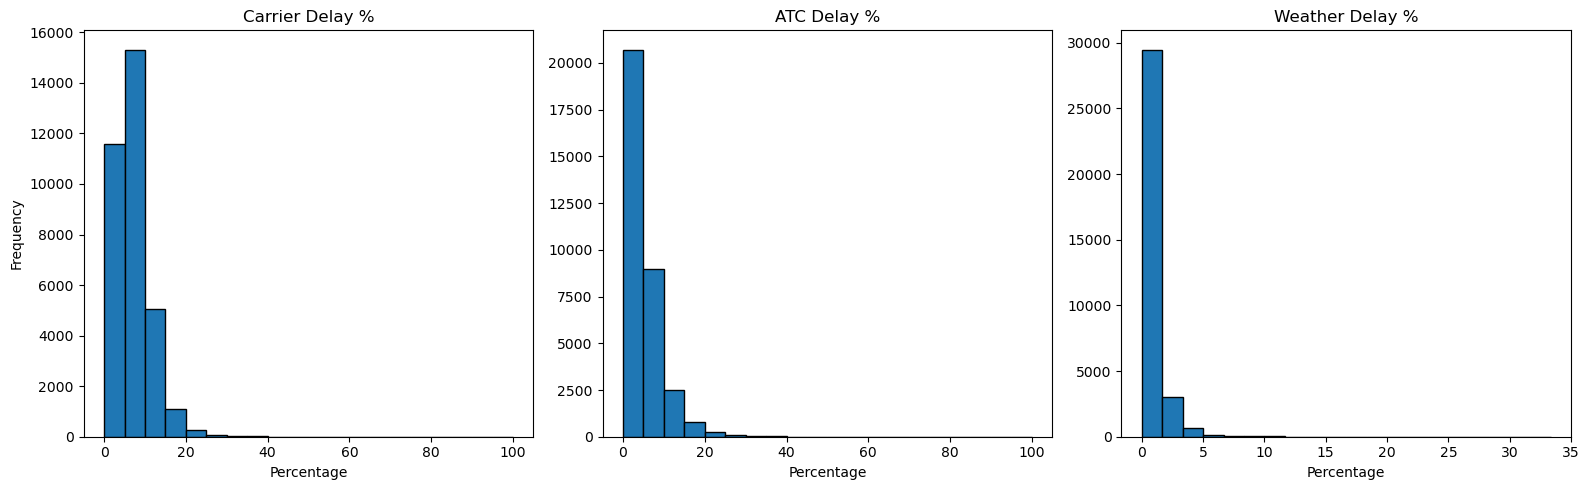

In [35]:
fig = plt.figure(figsize=(16,5))

# 3개의 subplot 으로 구성 : 열 구성
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.hist(airline_df['pct_carrier_delay'], bins=20, edgecolor='black')
ax2.hist(airline_df['pct_atc_delay'], bins=20, edgecolor='black')
ax3.hist(airline_df['pct_weather_delay'], bins=20, edgecolor='black')

# Add titles to each subplot
ax1.set_title('Carrier Delay %')
ax2.set_title('ATC Delay %')
ax3.set_title('Weather Delay %')

# Add x-labels to each subplot
ax1.set_xlabel('Percentage')
ax2.set_xlabel('Percentage')
ax3.set_xlabel('Percentage')

# Add y-label to the first subplot
ax1.set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

In [36]:
import seaborn as sns

<Axes: xlabel='airline', ylabel='pct_carrier_delay'>

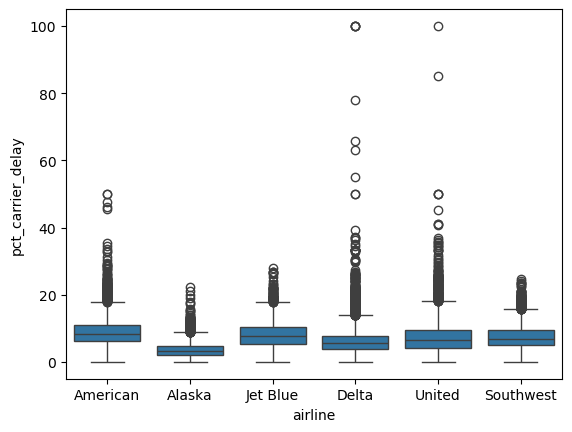

In [37]:
sns.boxplot(airline_df, x='airline', y='pct_carrier_delay')

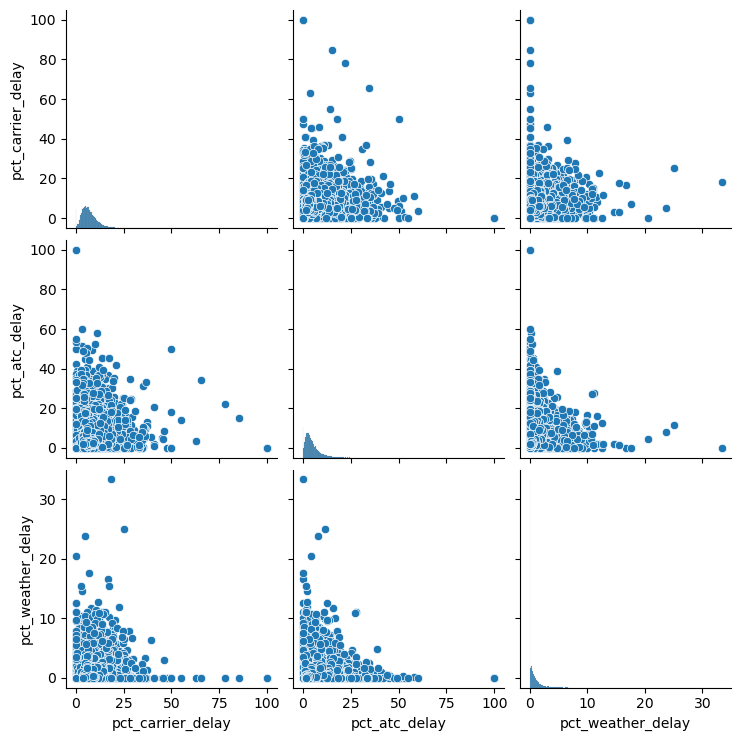

In [38]:
sns.pairplot(airline_df)

<Axes: >

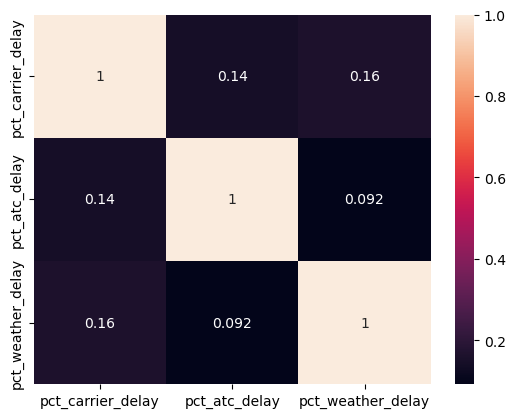

In [39]:
corr_matrix = airline_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)